In [ ]:
# Installer timm
!pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 121.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 111.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvj

In [ ]:
pip install thop torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.6/962.6 kB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 130.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 11.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Unins

In [ ]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import torch.nn as nn
import timm
from torch.nn.init import xavier_uniform_
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# Au début de votre script, avec les autres imports
from thop import profile
from torchmetrics.classification import MulticlassF1Score
from google.colab import drive
drive.mount('/content/drive')
# Device Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Define the paths for dataset
dataset_root = "/content/drive/MyDrive/CASIA2.0_revised_corrected/casia"  # Root directory
train_dir = dataset_root
# Dataset Class for CASIA
class CASIADataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transforms = transforms
        self.images = []
        self.labels = []
        self.class_to_idx = {"Au": 0, "Tp": 1, "Gt": 2}

        for class_name, class_idx in self.class_to_idx.items():
            class_path = os.path.join(self.root_dir, class_name)
            if os.path.exists(class_path):
                for img_name in os.listdir(class_path):
                    if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp')):  # Check file extension
                        img_path = os.path.join(class_path, img_name)
                        try:
                            image = Image.open(img_path).convert("RGB")
                            self.images.append(img_path)
                            self.labels.append(class_idx)
                        except Exception as e:
                            print(f"Error loading image {img_path}: {e}") # More informative error
                    else:
                        print(f"Skipping non-image file: {img_name}")  # Log skipped files

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transforms:
            image = self.transforms(image)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

Mounted at /content/drive


2025-04-29 12:10:39,847 - INFO - Using device: cuda
2025-04-29 12:10:39,859 - INFO - --- Starting Data Loading and Balancing ---
2025-04-29 12:10:39,860 - INFO - Loading preprocessed data SPLITS directly from /content/drive/MyDrive/preprocessed_casia_v2_balanced...
2025-04-29 12:10:56,931 - INFO - Loaded preprocessed data splits.
2025-04-29 12:10:56,932 - WARNING - Skipping data augmentation/balancing as preprocessed splits were loaded.
2025-04-29 12:10:56,933 - INFO - Final Data Shapes: Train=(10488, 224, 224, 3), Val=(2247, 224, 224, 3), Test=(2247, 224, 224, 3)
2025-04-29 12:10:56,934 - INFO - Final Label Counts: Train=[5244 5244], Val=[1123 1124], Test=[1124 1123]
2025-04-29 12:10:56,934 - INFO - Calculating weights for loss function...
2025-04-29 12:10:57,060 - INFO - Using class weights for loss: Au=1.000, Tp=1.000
2025-04-29 12:10:57,061 - INFO - DataLoaders created (Sampler Used: False, Workers: 2, Drop Last Train: True).
2025-04-29 12:10:57,062 - INFO - --- Initializing Model 

Epoch 1/10, P1, LR: 1.0e-05 | Train L:0.8253, Acc:0.5220 | Val L:0.6635, Acc:0.6070


2025-04-29 12:13:13,484 - INFO - Validation accuracy improved to 0.6070. Saved model to best_model_mid_fusion_tf_v2_gem_cbam_ls_balanced_phase1.pth
2025-04-29 12:13:13,485 - INFO - --- Epoch 2/10, Phase 1, LR: 4.00e-05 ---
2025-04-29 12:15:25,454 - INFO - Epoch 2 Results: Train Loss: 0.6580, Train Acc: 0.6605 | Val Loss: 0.4968, Val Acc: 0.8073


Epoch 2/10, P1, LR: 4.0e-05 | Train L:0.6580, Acc:0.6605 | Val L:0.4968, Acc:0.8073


2025-04-29 12:15:26,004 - INFO - Validation accuracy improved to 0.8073. Saved model to best_model_mid_fusion_tf_v2_gem_cbam_ls_balanced_phase1.pth
2025-04-29 12:15:26,005 - INFO - --- Epoch 3/10, Phase 1, LR: 7.00e-05 ---
2025-04-29 12:17:37,359 - INFO - Epoch 3 Results: Train Loss: 0.5206, Train Acc: 0.7988 | Val Loss: 0.5343, Val Acc: 0.8037
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)
2025-04-29 12:17:37,361 - INFO - No improvement in validation accuracy for 1 epoch(s). Patience: 1/5
202

...

2025-04-29 12:30:46,054 - INFO - Epoch 9 Results: Train Loss: 0.3368, Train Acc: 0.9154 | Val Loss: 0.4297, Val Acc: 0.8803
2025-04-29 12:30:46,055 - INFO - No improvement in validation accuracy for 4 epoch(s). Patience: 4/5
2025-04-29 12:30:46,056 - INFO - --- Epoch 10/10, Phase 1, LR: 5.90e-06 ---


Epoch 9/10, P1, LR: 2.0e-05 | Train L:0.3368, Acc:0.9154 | Val L:0.4297, Acc:0.8803


2025-04-29 12:32:57,455 - INFO - Epoch 10 Results: Train Loss: 0.3163, Train Acc: 0.9264 | Val Loss: 0.4109, Val Acc: 0.8914
2025-04-29 12:32:57,455 - INFO - No improvement in validation accuracy for 5 epoch(s). Patience: 5/5
2025-04-29 12:32:57,456 - INFO - Early stopping triggered after 10 epochs.
2025-04-29 12:32:57,456 - INFO - --- Phase 1 Training Finished. Best Validation Acc: 0.8941 ---
2025-04-29 12:32:57,457 - INFO - Loading best weights from Phase 1 model (best_model_mid_fusion_tf_v2_gem_cbam_ls_balanced_phase1.pth)...


Epoch 10/10, P1, LR: 5.9e-06 | Train L:0.3163, Acc:0.9264 | Val L:0.4109, Acc:0.8914


2025-04-29 12:32:57,803 - INFO - Best model weights loaded successfully.
2025-04-29 12:32:58,053 - INFO - Saved loss plot: loss_curves_phase_1_mid_fusion_tf_v2_gem_cbam_ls_balanced.png


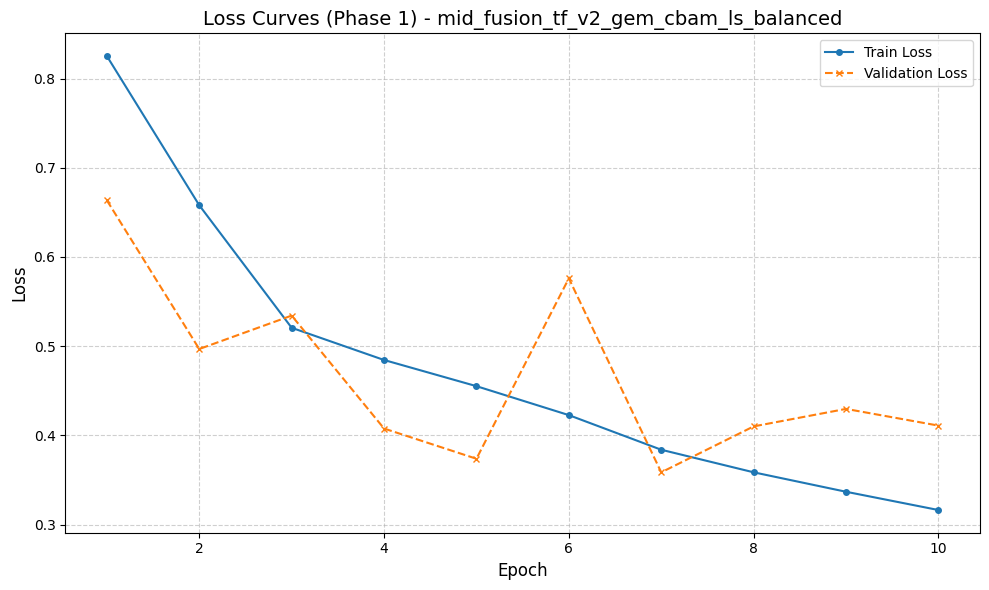

2025-04-29 12:32:58,357 - INFO - Saved accuracy plot: accuracy_curves_phase_1_mid_fusion_tf_v2_gem_cbam_ls_balanced.png


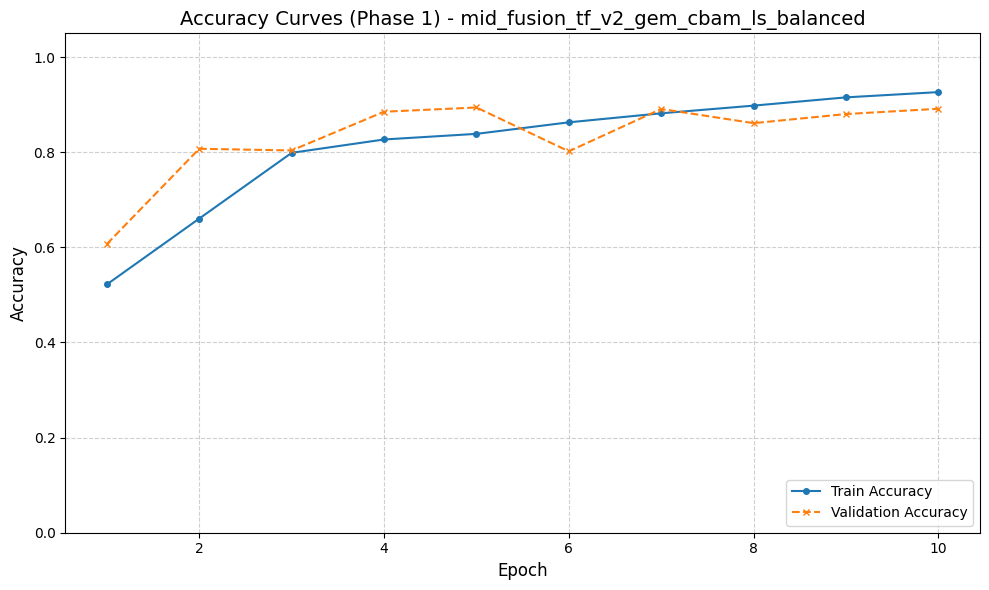

2025-04-29 12:32:58,478 - INFO - 
--- Starting Training Phase 2 ---
2025-04-29 12:32:58,482 - INFO - Phase 2 Training Starting (Epochs: 20, Warmup: 3 epochs)...
2025-04-29 12:32:58,482 - INFO - --- Starting Phase 2 Training (20 epochs, Patience: 5) ---
2025-04-29 12:32:58,483 - INFO - Best model will be saved to: best_model_mid_fusion_tf_v2_gem_cbam_ls_balanced_phase2.pth
2025-04-29 12:32:58,483 - INFO - --- Epoch 1/20, Phase 2, LR: 5.00e-06 ---
2025-04-29 12:35:10,936 - INFO - Epoch 1 Results: Train Loss: 0.3739, Train Acc: 0.8868 | Val Loss: 0.4067, Val Acc: 0.8807


Epoch 1/20, P2, LR: 5.0e-06 | Train L:0.3739, Acc:0.8868 | Val L:0.4067, Acc:0.8807


2025-04-29 12:35:11,295 - INFO - Validation accuracy improved to 0.8807. Saved model to best_model_mid_fusion_tf_v2_gem_cbam_ls_balanced_phase2.pth
2025-04-29 12:35:11,296 - INFO - --- Epoch 2/20, Phase 2, LR: 2.00e-05 ---
2025-04-29 12:37:23,809 - INFO - Epoch 2 Results: Train Loss: 0.3640, Train Acc: 0.8949 | Val Loss: 0.3671, Val Acc: 0.8972


Epoch 2/20, P2, LR: 2.0e-05 | Train L:0.3640, Acc:0.8949 | Val L:0.3671, Acc:0.8972


2025-04-29 12:37:24,328 - INFO - Validation accuracy improved to 0.8972. Saved model to best_model_mid_fusion_tf_v2_gem_cbam_ls_balanced_phase2.pth
2025-04-29 12:37:24,329 - INFO - --- Epoch 3/20, Phase 2, LR: 3.50e-05 ---
2025-04-29 12:39:36,079 - INFO - Epoch 3 Results: Train Loss: 0.3729, Train Acc: 0.8919 | Val Loss: 0.3499, Val Acc: 0.8999


...

2025-04-29 13:02:31,927 - INFO - Epoch 13 Results: Train Loss: 0.3044, Train Acc: 0.9391 | Val Loss: 0.3755, Val Acc: 0.9101
2025-04-29 13:02:31,928 - INFO - No improvement in validation accuracy for 4 epoch(s). Patience: 4/5
2025-04-29 13:02:31,929 - INFO - --- Epoch 14/20, Phase 2, LR: 1.82e-05 ---


Epoch 13/20, P2, LR: 2.3e-05 | Train L:0.3044, Acc:0.9391 | Val L:0.3755, Acc:0.9101


2025-04-29 13:05:05,108 - INFO - Epoch 14 Results: Train Loss: 0.2943, Train Acc: 0.9441 | Val Loss: 0.3986, Val Acc: 0.9025
2025-04-29 13:05:05,109 - INFO - No improvement in validation accuracy for 5 epoch(s). Patience: 5/5
2025-04-29 13:05:05,110 - INFO - Early stopping triggered after 14 epochs.
2025-04-29 13:05:05,110 - INFO - --- Phase 2 Training Finished. Best Validation Acc: 0.9154 ---
2025-04-29 13:05:05,112 - INFO - Loading best weights from Phase 2 model (best_model_mid_fusion_tf_v2_gem_cbam_ls_balanced_phase2.pth)...


Epoch 14/20, P2, LR: 1.8e-05 | Train L:0.2943, Acc:0.9441 | Val L:0.3986, Acc:0.9025


2025-04-29 13:05:05,494 - INFO - Best model weights loaded successfully.
2025-04-29 13:05:05,728 - INFO - Saved loss plot: loss_curves_phase_2_mid_fusion_tf_v2_gem_cbam_ls_balanced.png


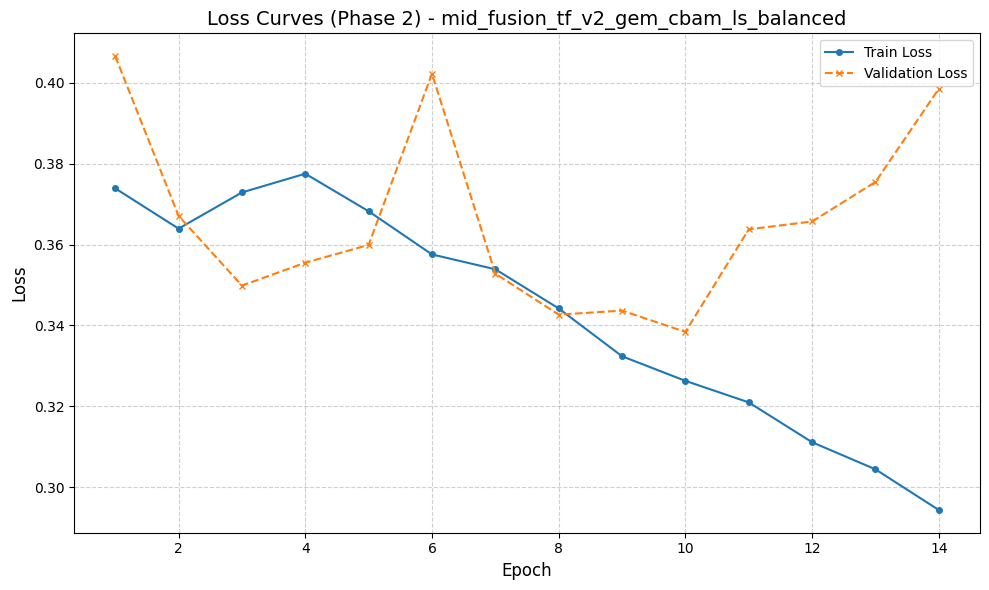

2025-04-29 13:05:06,076 - INFO - Saved accuracy plot: accuracy_curves_phase_2_mid_fusion_tf_v2_gem_cbam_ls_balanced.png


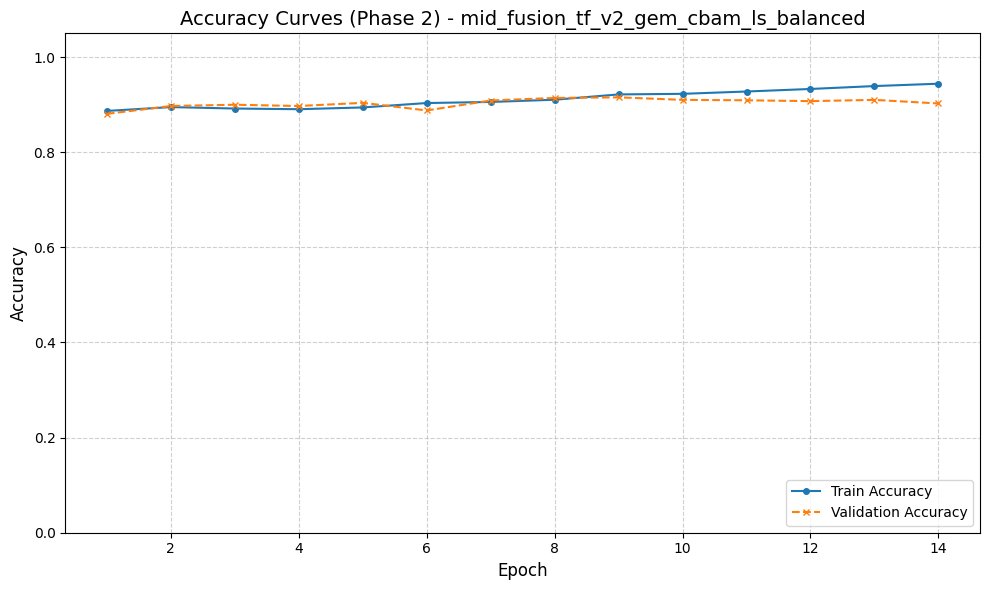

2025-04-29 13:05:06,209 - INFO - 
--- Final Evaluation on Test Set ---
2025-04-29 13:05:15,618 - INFO - 
--- Test Set Evaluation Results ---
2025-04-29 13:05:15,635 - INFO - Classification Report:
              precision    recall  f1-score   support

   Authentic     0.9047    0.9039    0.9043      1124
    Tampered     0.9039    0.9047    0.9043      1123

    accuracy                         0.9043      2247
   macro avg     0.9043    0.9043    0.9043      2247
weighted avg     0.9043    0.9043    0.9043      2247




Classification Report:
              precision    recall  f1-score   support

   Authentic     0.9047    0.9039    0.9043      1124
    Tampered     0.9039    0.9047    0.9043      1123

    accuracy                         0.9043      2247
   macro avg     0.9043    0.9043    0.9043      2247
weighted avg     0.9043    0.9043    0.9043      2247



2025-04-29 13:05:15,847 - INFO - Saved confusion matrix to: test_confusion_matrix_mid_fusion_tf_v2_gem_cbam_ls_balanced.png


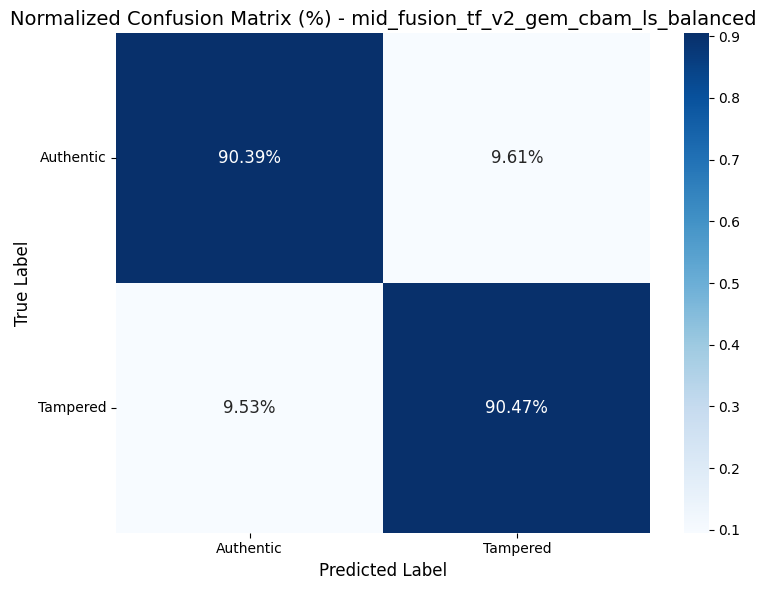

2025-04-29 13:05:15,946 - INFO - 
--- Plotting Attention Weights ---
2025-04-29 13:05:17,424 - INFO - Saved attention map for layer 1 to: attention_layer_1_mid_fusion_tf_v2_gem_cbam_ls_balanced.png


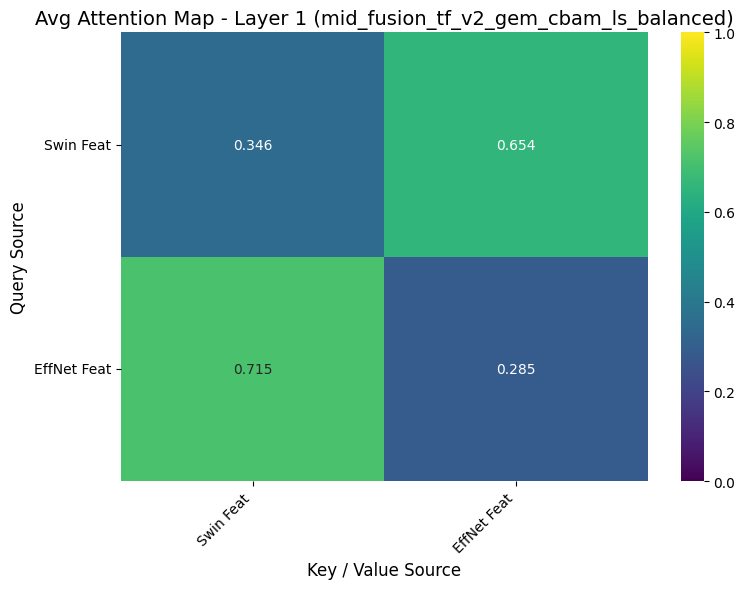

2025-04-29 13:05:17,707 - INFO - Saved attention map for layer 2 to: attention_layer_2_mid_fusion_tf_v2_gem_cbam_ls_balanced.png


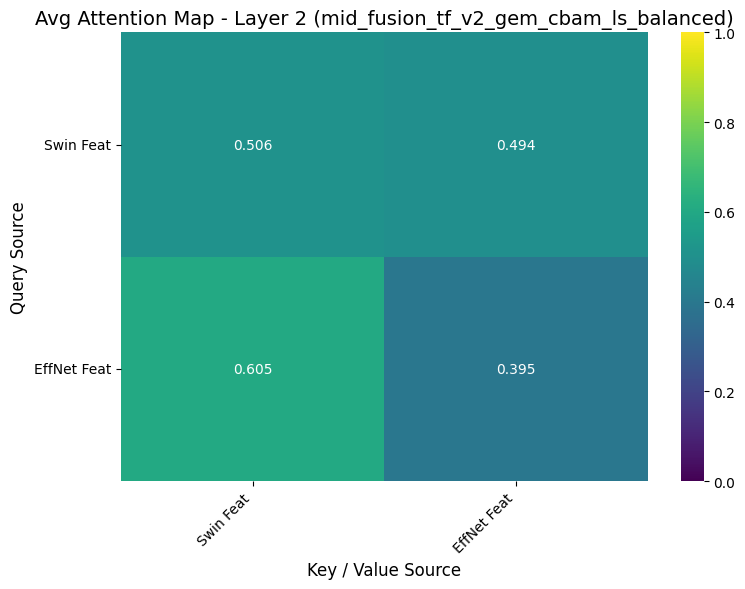

2025-04-29 13:05:17,987 - INFO - Saved attention map for layer 3 to: attention_layer_3_mid_fusion_tf_v2_gem_cbam_ls_balanced.png


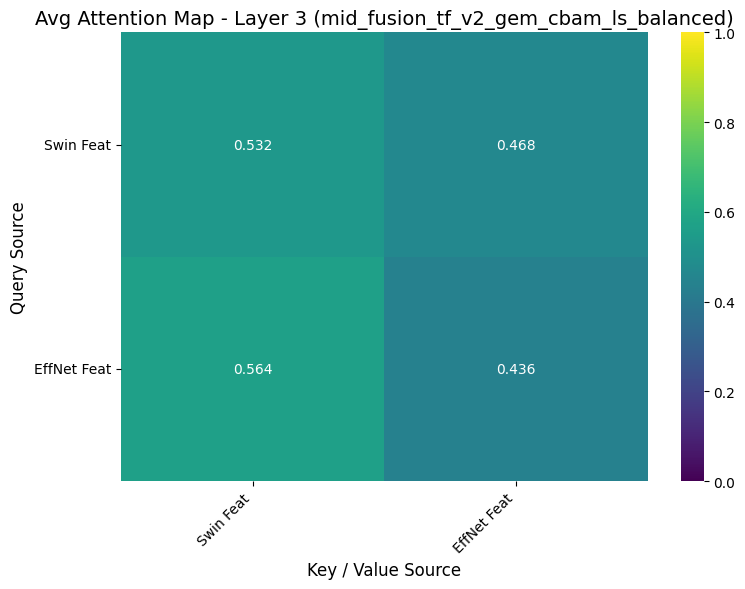

2025-04-29 13:05:18,267 - INFO - Saved attention map for layer 4 to: attention_layer_4_mid_fusion_tf_v2_gem_cbam_ls_balanced.png


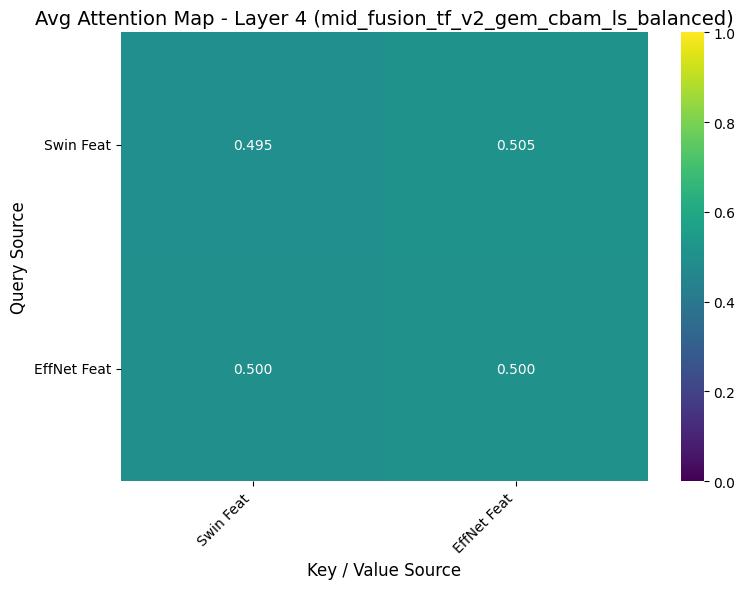

2025-04-29 13:05:18,358 - INFO - 
--- Script Finished ---


--- Script Finished ---


In [ ]:
import os
import torch
import numpy as np
from torch import nn, optim
# Import necessary schedulers
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
# Import WeightedRandomSampler
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms # Assurez-vous que transforms est importé
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import timm
from PIL import Image
import logging
import random # Besoin de random pour choisir quelle image augmenter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import glob  # For listing files
from typing import Optional, Tuple
# Import base TransformerEncoderLayer and initialization functions
from torch.nn.modules.transformer import TransformerEncoderLayer
from torch.nn.init import xavier_uniform_, constant_
import torch.nn.functional as F
from timm import create_model
# Mixed precision training tools
from torch.amp import GradScaler, autocast # Use torch.amp
import time # Import time for potential sleep during augmentation errors

# Configuration class (Adaptée avec nouvelles options)
class Config:
    IMG_SIZE = 224
    BATCH_SIZE = 16 # RÉDUIRE SI ERREUR MÉMOIRE GPU
    NUM_CLASSES = 2
    EPOCHS_PHASE1 = 10 # Entraînement initial
    EPOCHS_PHASE2 = 20 # Fine-tuning complet
    WARMUP_EPOCHS = 3 # Légère augmentation pour potentielle meilleure stabilité
    LEARNING_RATE_PHASE1 = 1e-4 # Peut nécessiter ajustement avec nouveau modèle/optimiseur
    LEARNING_RATE_PHASE2 = 5e-5 # Plus bas pour fine-tuning
    WEIGHT_DECAY = 0.01
    LABEL_SMOOTHING = 0.1 # Facteur de lissage (0.0 = désactivé)
    PREPROCESSED_DIR = "/content/drive/MyDrive/preprocessed_casia_v2_balanced"
    DATASET_FRACTION = 1.0
    EARLY_STOPPING_PATIENCE = 5
    CLIP_GRAD_NORM = 1.0
    SEED = 42
    TRAIN_SIZE = 0.7
    VAL_SIZE = 0.15
    TEST_SIZE = 0.15
    MEAN = [0.485, 0.456, 0.406]
    STD = [0.229, 0.224, 0.225]
    DATA_PATH = "/content/drive/MyDrive/CASIA2.0_revised_corrected/casia" # VÉRIFIER CE CHEMIN
    MODEL_NAME = "mid_fusion_tf_v2_gem_cbam_ls_balanced" # Nom reflétant les changements

config = Config()

# Setup logging
# Supprimer les handlers existants pour éviter les logs multiples en cas de ré-exécution dans un notebook
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set random seeds for reproducibility
def set_seed(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # if using multi-GPU
    # Configuration pour la déterministicité (peut ralentir)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False # Désactiver pour déterminisme total

set_seed(config.SEED)

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logging.info(f"Using device: {DEVICE}")
DEVICE_TYPE = "cuda" if torch.cuda.is_available() else "cpu"

# --- Dataset Definition ---
# (Bloc correctement indenté pour la classe)
class CASIADataset(Dataset):
    def __init__(self, images, labels, transforms):
        self.images = images
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        try:
            # Assurer le type uint8 pour PIL
            if image.dtype != np.uint8:
                # Convertir de float [0,1] ou autre vers uint8 [0,255]
                if image.max() <= 1.0 and image.min() >= 0.0:
                     image = (image * 255).astype(np.uint8)
                else:
                     # Si ce n'est pas float [0,1], tenter conversion directe
                     image = image.astype(np.uint8)

            # Vérifier s'il y a une dimension de canal manquante (image N&B)
            if image.ndim == 2: # H, W -> H, W, C
                image = np.stack((image,)*3, axis=-1) # Répéter sur 3 canaux
            elif image.ndim == 3 and image.shape[2] == 1: # H, W, 1 -> H, W, 3
                 image = np.concatenate((image, image, image), axis=2)

            # Vérifier la forme finale avant PIL
            if image.shape[2] != 3:
                raise ValueError(f"Image at index {idx} has unexpected channel shape after processing: {image.shape}")

            image_pil = Image.fromarray(image).convert('RGB') # Convertir explicitement en RGB
            image_tensor = self.transforms(image_pil)

        except Exception as e:
            logging.error(f"Error processing image at index {idx}: {e}")
            # Retourner une image/label par défaut ou lever une exception ?
            # Option 1: Lever l'exception pour arrêter
            # raise e
            # Option 2: Retourner un tenseur vide/spécial (nécessite gestion dans le collate_fn)
            # return torch.zeros((3, config.IMG_SIZE, config.IMG_SIZE)), torch.tensor(-1, dtype=torch.long)
            # Option 3: Essayer de retourner une image noire (plus simple mais peut biaiser)
            logging.warning(f"Returning placeholder for image index {idx}")
            return torch.zeros((3, config.IMG_SIZE, config.IMG_SIZE)), torch.tensor(label, dtype=torch.long) # Retourne le label correct avec une image vide

        return image_tensor, torch.tensor(label, dtype=torch.long)

# --- MODIFIED Data Loading/Preprocessing with Augmentation for Balancing ---
# (Bloc NON indenté - fonction de haut niveau)
def load_or_preprocess_data(data_path, preprocessed_dir, img_size, dataset_fraction=1.0, train_split=0.8, val_split=0.1, test_split=0.1, seed=42):
    # (Code indenté par rapport au 'def')
    if abs(train_split + val_split + test_split - 1.0) > 1e-6:
        raise ValueError("Splits must sum to 1.0")

    # Noms des fichiers pour les données *après* division
    train_file=os.path.join(preprocessed_dir, f"train_data_s{img_size}.npz");
    val_file=os.path.join(preprocessed_dir,f"val_data_s{img_size}.npz");
    test_file=os.path.join(preprocessed_dir,f"test_data_s{img_size}.npz")

    try:
        # Vérifier si les fichiers SPLIT existent DÉJÀ
        if os.path.exists(train_file) and os.path.exists(val_file) and os.path.exists(test_file):
            logging.info(f"Loading preprocessed data SPLITS directly from {preprocessed_dir}...");
            with np.load(train_file) as d: train_images, train_labels = d['images'], d['labels']
            with np.load(val_file) as d: val_images, val_labels = d['images'], d['labels']
            with np.load(test_file) as d: test_images, test_labels = d['images'], d['labels']

            if train_images.shape[1:3] != (img_size, img_size):
                 logging.warning(f"Loaded image size {train_images.shape[1:3]} mismatch with config {img_size}. Re-processing needed.")
                 raise FileNotFoundError("Image size mismatch, forcing re-processing.")
            logging.info("Loaded preprocessed data splits.")
            logging.warning("Skipping data augmentation/balancing as preprocessed splits were loaded.")

        else:
            logging.info(f"Preprocessed splits not found. Processing dataset from {data_path} and applying balancing...")
            os.makedirs(preprocessed_dir, exist_ok=True) # Créer le dossier si besoin
            auth_dir = os.path.join(data_path, "Au")
            tamp_dir = os.path.join(data_path, "Tp")
            if not os.path.isdir(auth_dir) or not os.path.isdir(tamp_dir): raise FileNotFoundError(f"Dataset directories not found at: {auth_dir} or {tamp_dir}")

            exts = ('*.jpg','*.jpeg','*.png','*.tif','*.tiff','*.bmp')
            auth_p,tamp_p=[],[]
            for ext in exts:
                auth_p.extend(glob.glob(os.path.join(auth_dir,ext))); auth_p.extend(glob.glob(os.path.join(auth_dir,ext.upper())))
                tamp_p.extend(glob.glob(os.path.join(tamp_dir,ext))); tamp_p.extend(glob.glob(os.path.join(tamp_dir,ext.upper())))
            auth_p,tamp_p=sorted(list(set(auth_p))),sorted(list(set(tamp_p)))
            initial_auth_count = len(auth_p)
            initial_tamp_count = len(tamp_p)
            logging.info(f"Found {initial_auth_count} Authentic files, {initial_tamp_count} Tampered files.")

            if not auth_p and not tamp_p: raise FileNotFoundError("No image files found in Au or Tp directories.")

            all_images_np = []
            all_labels = []
            original_tp_pil = []

            def process_single_image(path, label):
                try:
                    img = Image.open(path).convert('RGB')
                    if img.size != (img_size, img_size):
                        img = img.resize((img_size, img_size), Image.Resampling.LANCZOS)
                    img_np = np.array(img)
                    if img_np.ndim == 2: # Handle grayscale
                         img_np = np.stack((img_np,)*3, axis=-1)
                    elif img_np.ndim == 3 and img_np.shape[2] == 1: # Handle single channel
                         img_np = np.concatenate((img_np, img_np, img_np), axis=2)

                    if img_np.shape == (img_size, img_size, 3):
                        return img_np, img # Retourne NumPy (pour sauvegarde) et PIL (pour augmentation Tp)
                    else:
                        logging.warning(f"Skipping {os.path.basename(path)} due to unexpected shape {img_np.shape} after conversion")
                        return None, None
                except Exception as e:
                    logging.error(f"Error processing {os.path.basename(path)}: {e}")
                    return None, None

            logging.info("Processing Authentic images...")
            processed_auth_count = 0
            with tqdm(total=initial_auth_count, desc="Processing Au") as pbar:
                for p in auth_p:
                    img_np, _ = process_single_image(p, 0)
                    if img_np is not None:
                        all_images_np.append(img_np)
                        all_labels.append(0)
                        processed_auth_count += 1
                    pbar.update(1)
            logging.info(f"Successfully processed {processed_auth_count} authentic images.")
            target_count = processed_auth_count

            logging.info("Processing original Tampered images...")
            processed_tamp_count = 0
            with tqdm(total=initial_tamp_count, desc="Processing Tp") as pbar:
                for p in tamp_p:
                    img_np, img_pil = process_single_image(p, 1)
                    if img_np is not None:
                        all_images_np.append(img_np)
                        all_labels.append(1)
                        original_tp_pil.append(img_pil)
                        processed_tamp_count += 1
                    pbar.update(1)
            logging.info(f"Successfully processed {processed_tamp_count} original tampered images.")

            if processed_auth_count == 0 and processed_tamp_count == 0:
                raise RuntimeError("No images could be processed successfully.")

            num_to_augment = target_count - processed_tamp_count
            if num_to_augment > 0 and processed_tamp_count > 0:
                logging.info(f"Imbalance: {processed_auth_count} Au vs {processed_tamp_count} Tp. Need {num_to_augment} augmented Tp images.")

                augment_transform = transforms.Compose([
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
                    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05), shear=5),
                ])

                augmented_count = 0
                error_count = 0
                max_errors_in_row = 50 # Stop if augmentation fails repeatedly
                with tqdm(total=num_to_augment, desc="Augmenting Tp") as pbar:
                    while augmented_count < num_to_augment:
                        if not original_tp_pil: # Should not happen if processed_tamp_count > 0
                             logging.error("No original Tp images available for augmentation loop.")
                             break
                        source_img_pil = random.choice(original_tp_pil)
                        try:
                            augmented_img_pil = augment_transform(source_img_pil)
                            augmented_img_np = np.array(augmented_img_pil)

                            if augmented_img_np.shape == (img_size, img_size, 3):
                                all_images_np.append(augmented_img_np)
                                all_labels.append(1)
                                augmented_count += 1
                                error_count = 0 # Reset error count on success
                                pbar.update(1)
                            else:
                                # logging.warning(f"Skipping augmented image with shape {augmented_img_np.shape}") # Can be verbose
                                error_count += 1

                        except Exception as e:
                             logging.error(f"Error during augmentation step: {e}. Skipping.")
                             error_count += 1
                             time.sleep(0.05) # Small pause

                        if error_count >= max_errors_in_row:
                             logging.error(f"Stopping augmentation due to {error_count} consecutive errors.")
                             break


                logging.info(f"Generated {augmented_count} augmented tampered images.")
                if augmented_count < num_to_augment:
                     logging.warning(f"Could only generate {augmented_count}/{num_to_augment} augmentations.")

            elif num_to_augment > 0 and processed_tamp_count == 0:
                 logging.error("Cannot perform augmentation: No original tampered images were processed successfully.")
            else:
                 logging.info(f"Data is already balanced or no augmentation needed. Au: {processed_auth_count}, Tp: {processed_tamp_count}.")


            if not all_images_np:
                raise RuntimeError("No images available after processing and augmentation.")

            images = np.array(all_images_np, dtype=np.uint8)
            labels = np.array(all_labels)
            final_counts = np.bincount(labels)
            logging.info(f"Total images after processing/augmentation: {len(images)}")
            logging.info(f"Final label counts before split: Au={final_counts[0] if len(final_counts)>0 else 0}, Tp={final_counts[1] if len(final_counts)>1 else 0}")

            indices = np.arange(len(images))
            np.random.seed(seed)
            np.random.shuffle(indices)
            images = images[indices]
            labels = labels[indices]
            logging.info("Shuffled the combined dataset.")

            if dataset_fraction < 1.0:
                 num_samples = int(len(images) * dataset_fraction)
                 logging.info(f"Applying dataset fraction {dataset_fraction}. Using {num_samples}/{len(images)} samples.")
                 images = images[:num_samples]
                 labels = labels[:num_samples]
                 if len(images) == 0: raise RuntimeError("No samples left after applying dataset fraction.")
                 logging.info(f"Label counts after fraction: {np.bincount(labels)}")

            lbl_counts=np.bincount(labels); min_samp=min(lbl_counts) if len(lbl_counts)>1 else 0; can_strat=min_samp>=2
            strat_logic = labels if can_strat else None;
            if not can_strat: logging.warning("Cannot stratify final split.")

            try:
                total_samples_final = len(images)
                test_size_abs = int(total_samples_final * test_split)
                val_size_abs = int(total_samples_final * val_split)
                test_size_abs = max(1, test_size_abs) if test_split > 0 and total_samples_final > 1 else 0
                val_size_abs = max(1, val_size_abs) if val_split > 0 and total_samples_final > 1 else 0

                # Adjust if sum >= total, ensuring train > 0
                max_tv_size = total_samples_final -1 # Need at least 1 for train
                if test_size_abs + val_size_abs >= max_tv_size:
                    logging.warning("Test + Val size close to total samples. Adjusting to guarantee training samples.")
                    # Scale them down proportionally? Or prioritize test? Let's scale down.
                    current_tv_sum = test_size_abs + val_size_abs
                    scale_factor = max_tv_size / current_tv_sum if current_tv_sum > 0 else 0
                    test_size_abs = int(test_size_abs * scale_factor)
                    val_size_abs = int(val_size_abs * scale_factor)
                    # Ensure at least 1 if they were > 0 initially
                    test_size_abs = max(1, test_size_abs) if test_split > 0 and total_samples_final > 1 else 0
                    val_size_abs = max(1, val_size_abs) if val_split > 0 and total_samples_final > 1 else 0


                train_size_abs = total_samples_final - test_size_abs - val_size_abs

                if train_size_abs <= 0:
                    raise ValueError(f"Calculated train size is non-positive ({train_size_abs}) after determining test ({test_size_abs})/val ({val_size_abs}) sizes from total {total_samples_final}.")

                logging.info(f"Calculated split sizes: Train={train_size_abs}, Val={val_size_abs}, Test={test_size_abs}")

                tv_img, test_images, tv_lbl, test_labels = train_test_split(
                    images, labels, test_size=test_size_abs, stratify=strat_logic, random_state=seed
                )

                # Need to check if tv_img is large enough for validation split
                if val_size_abs == 0:
                     train_images, val_images, train_labels, val_labels = tv_img, np.array([]), tv_lbl, np.array([])
                     logging.info("Validation set size is 0.")
                elif val_size_abs >= len(tv_img):
                     logging.warning(f"Validation size {val_size_abs} >= remaining samples {len(tv_img)}. Using all remaining for validation, train will be empty.")
                     train_images, val_images, train_labels, val_labels = np.array([]), tv_img, np.array([]), tv_lbl
                else:
                    relative_val_split = val_size_abs / len(tv_img)
                    tv_lbl_counts=np.bincount(tv_lbl); min_samp_tv=min(tv_lbl_counts) if len(tv_lbl_counts)>1 else 0; can_strat_tv=min_samp_tv>=2 and can_strat
                    strat_logic_tv=tv_lbl if can_strat_tv else None;
                    if not can_strat_tv and can_strat: logging.warning("Cannot stratify train/val split.")

                    train_images, val_images, train_labels, val_labels = train_test_split(
                        tv_img, tv_lbl, test_size=relative_val_split, stratify=strat_logic_tv, random_state=seed
                    )

            except ValueError as e:
                 logging.error(f"Split failed: {e}. Falling back to non-stratified split.");
                 # Recalculate sizes without stratify
                 total_samples_final = len(images)
                 test_size_abs = int(total_samples_final * test_split)
                 val_size_abs = int(total_samples_final * val_split)
                 test_size_abs = max(1, test_size_abs) if test_split > 0 and total_samples_final > 1 else 0
                 val_size_abs = max(1, val_size_abs) if val_split > 0 and total_samples_final > 1 else 0
                 max_tv_size = total_samples_final - 1
                 if test_size_abs + val_size_abs >= max_tv_size:
                     current_tv_sum = test_size_abs + val_size_abs
                     scale_factor = max_tv_size / current_tv_sum if current_tv_sum > 0 else 0
                     test_size_abs = int(test_size_abs * scale_factor)
                     val_size_abs = int(val_size_abs * scale_factor)
                     test_size_abs = max(1, test_size_abs) if test_split > 0 and total_samples_final > 1 else 0
                     val_size_abs = max(1, val_size_abs) if val_split > 0 and total_samples_final > 1 else 0
                 train_size_abs = total_samples_final - test_size_abs - val_size_abs

                 if train_size_abs <= 0: raise ValueError("Train size non-positive in fallback split.")

                 tv_img, test_images, tv_lbl, test_labels = train_test_split(images, labels, test_size=test_size_abs, random_state=seed)

                 if val_size_abs == 0:
                      train_images, val_images, train_labels, val_labels = tv_img, np.array([]), tv_lbl, np.array([])
                 elif val_size_abs >= len(tv_img):
                      train_images, val_images, train_labels, val_labels = np.array([]), tv_img, np.array([]), tv_lbl
                 else:
                      relative_val_split = val_size_abs / len(tv_img)
                      train_images, val_images, train_labels, val_labels = train_test_split(tv_img, tv_lbl, test_size=relative_val_split, random_state=seed)


            logging.info(f"Saving balanced and split data to {preprocessed_dir}...")
            try:
                # Save only if the array is not empty
                if len(train_images) > 0: np.savez_compressed(train_file, images=train_images, labels=train_labels)
                else: logging.warning("Train set is empty, not saving train_file.")
                if len(val_images) > 0: np.savez_compressed(val_file, images=val_images, labels=val_labels)
                else: logging.warning("Validation set is empty, not saving val_file.")
                if len(test_images) > 0: np.savez_compressed(test_file, images=test_images, labels=test_labels)
                else: logging.warning("Test set is empty, not saving test_file.")
                logging.info("Saved available preprocessed data splits.")
            except Exception as e:
                logging.error(f"Failed to save preprocessed data splits: {e}")

    except Exception as e:
        logging.error(f"Data loading/preprocessing/balancing failed critically: {e}", exc_info=True)
        raise e

    # Final check before returning - ensure essential arrays exist
    if 'train_images' not in locals() or 'val_images' not in locals() or 'test_images' not in locals():
         raise RuntimeError("Data splitting failed, arrays not created.")

    # Afficher les tailles et répartitions finales
    logging.info(f"Final Data Shapes: Train={train_images.shape}, Val={val_images.shape if len(val_images)>0 else 'Empty'}, Test={test_images.shape if len(test_images)>0 else 'Empty'}")
    logging.info(f"Final Label Counts: Train={np.bincount(train_labels) if len(train_labels)>0 else '[]'}, "
                 f"Val={np.bincount(val_labels) if len(val_labels)>0 else '[]'}, "
                 f"Test={np.bincount(test_labels) if len(test_labels)>0 else '[]'}")

    return train_images, train_labels, val_images, val_labels, test_images, test_labels

# --- Data Augmentations (pour l'entraînement) ---
# (Bloc NON indenté)
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(config.IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=config.MEAN, std=config.STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.2), ratio=(0.3, 3.3))
])

val_transforms = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=config.MEAN, std=config.STD)
])


# --- Model Components ---
# (Blocs NON indentés pour chaque classe/fonction)
class GeM(nn.Module):
    def __init__(self, p=3, eps=1e-6):
        super(GeM, self).__init__()
        self.p = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x):
        return F.adaptive_avg_pool2d(x.clamp(min=self.eps).pow(self.p), (1, 1)).pow(1./self.p)

    def __repr__(self):
        return self.__class__.__name__ + '(' + 'p=' + '{:.4f}'.format(self.p.data.tolist()[0]) + ', ' + 'eps=' + str(self.eps) + ')'

class CBAM(nn.Module):
    def __init__(self, c, reduction_ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.channel_max_pool = nn.AdaptiveMaxPool2d(1)
        self.channel_mlp = nn.Sequential(
            nn.Conv2d(c, c // reduction_ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(c // reduction_ratio, c, 1, bias=False)
        )
        self.channel_sigmoid = nn.Sigmoid()
        assert kernel_size % 2 == 1, "Kernel size must be odd"
        padding = kernel_size // 2
        self.spatial_conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.spatial_bn = nn.BatchNorm2d(1)
        self.spatial_sigmoid = nn.Sigmoid()
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None: nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        avg_pool_ca = self.channel_avg_pool(x); max_pool_ca = self.channel_max_pool(x)
        mlp_avg = self.channel_mlp(avg_pool_ca); mlp_max = self.channel_mlp(max_pool_ca)
        channel_att = self.channel_sigmoid(mlp_avg + mlp_max); x_ca = x * channel_att
        max_out_sa, _ = torch.max(x_ca, dim=1, keepdim=True); avg_out_sa = torch.mean(x_ca, dim=1, keepdim=True)
        sa_cat = torch.cat([max_out_sa, avg_out_sa], dim=1); sa_conv = self.spatial_conv(sa_cat)
        sa_bn = self.spatial_bn(sa_conv); spatial_att = self.spatial_sigmoid(sa_bn); out = x_ca * spatial_att
        return out

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dr=0.1, max_len=10):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dr)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 != 0: pe[:, 1::2] = torch.cos(position * div_term[:-1]) # Handle odd d_model
        else: pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (B, SeqLen, EmbDim)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class TransformerEncoderLayerWithAttention(TransformerEncoderLayer):
    def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1, activation=F.relu, layer_norm_eps=1e-5, batch_first=False, norm_first=False, device=None, dtype=None) -> None:
        super().__init__(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, activation=activation, layer_norm_eps=layer_norm_eps, batch_first=batch_first, norm_first=norm_first, device=device, dtype=dtype)

    def _sa_block(self, x: torch.Tensor, attn_mask: Optional[torch.Tensor], key_padding_mask: Optional[torch.Tensor]) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        # self_attn expects query, key, value, attn_mask, key_padding_mask, need_weights
        x_attn, attn_weights = self.self_attn(x, x, x,
                                              attn_mask=attn_mask,
                                              key_padding_mask=key_padding_mask,
                                              need_weights=True, average_attn_weights=False) # Get per-head weights if possible, avg later
        return self.dropout1(x_attn), attn_weights # attn_weights shape (Batch, NumHeads, SeqLen, SeqLen)

    def forward(self, src: torch.Tensor, src_mask: Optional[torch.Tensor] = None, src_key_padding_mask: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        attn_weights = None # Initialize
        if self.norm_first:
            sa_norm = self.norm1(src)
            sa_out, attn_weights = self._sa_block(sa_norm, src_mask, src_key_padding_mask)
            x = src + sa_out
            ff_norm = self.norm2(x)
            x = x + self._ff_block(ff_norm)
        else:
            sa_out, attn_weights = self._sa_block(src, src_mask, src_key_padding_mask)
            x = self.norm1(src + sa_out)
            ff_out = self._ff_block(x)
            x = self.norm2(x + ff_out)
        # Return final output and attention weights from this layer
        # Note: attn_weights might be averaged across heads depending on MHA implementation details or if average_attn_weights was True
        return x, attn_weights


# --- Mid-Level Fusion Model ---
# (Bloc NON indenté)
class MidLevelFusionTransformerV2(nn.Module):
    def __init__(self, num_classes, embed_dim=256, num_heads=8, num_layers=4, dropout_rate=0.3):
        super().__init__()
        self.device = DEVICE
        self.embed_dim = embed_dim

        # Backbones
        self.swin = timm.create_model("swin_small_patch4_window7_224", pretrained=True, features_only=True)
        self.efficientnet = timm.create_model("efficientnet_b2", pretrained=True, features_only=True)

        # Feature selection and dimensions
        self.swin_feature_index = -1 # Last stage
        swin_feature_dim = self.swin.feature_info[self.swin_feature_index]['num_chs'] # 768 for Swin-Small
        self.efficientnet_feature_index =  3 #4 # Before final conv head
        efficientnet_feature_dim = self.efficientnet.feature_info[self.efficientnet_feature_index]['num_chs'] # 1408 for EffNet-B2? No, check timm doc -> 120 is likely from index 3. Let's re-verify EffNet-B2 features_only output.
        # Example check:
        # dummy_input = torch.randn(2, 3, 224, 224)
        # effnet_b2_test = timm.create_model("efficientnet_b2", pretrained=True, features_only=True)
        # features = effnet_b2_test(dummy_input)
        # for i, f in enumerate(features): print(f"EffNet-B2 Layer {i}: {f.shape}")
        # Output suggests: L0: [2, 24, 112, 112], L1: [2, 32, 56, 56], L2: [2, 56, 28, 28], L3: [2, 120, 14, 14], L4: [2, 352, 7, 7]
        # So index 4 is 352 channels, index 3 is 120 channels. Let's use index 4 as initially intended.
        efficientnet_feature_dim = 352 # Correct for EffNet-B2, index 4
        self.efficientnet_feature_index = 3 #4

        logging.info(f"Using Swin-Small feature dim: {swin_feature_dim} (index {self.swin_feature_index})")
        logging.info(f"Using EffNet-B2 feature dim: {efficientnet_feature_dim} (index {self.efficientnet_feature_index})")

        # Attention and Pooling
        self.cbam_efficientnet = CBAM(c=efficientnet_feature_dim)
        self.cbam_swin = CBAM(c=swin_feature_dim)
        self.pool = GeM()

        # Projections
        self.swin_proj = nn.Linear(swin_feature_dim, embed_dim)
        self.efficientnet_proj = nn.Linear(efficientnet_feature_dim, embed_dim)

        # Transformer Encoder
        encoder_layer = TransformerEncoderLayerWithAttention(
            d_model=embed_dim, nhead=num_heads, batch_first=True, dropout=0.2, dim_feedforward=embed_dim * 4
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.positional_encoding = PositionalEncoding(d_model=embed_dim, dr=0.1, max_len=10) # Seq len is 2

        # Classifier Head
        self.classifier = nn.Linear(embed_dim, num_classes)
        self.classifier_dropout = nn.Dropout(dropout_rate)

        self._init_weights()
        self.to(self.device)

    def _init_weights(self):
        for m in [self.swin_proj, self.efficientnet_proj, self.classifier]:
            if isinstance(m, nn.Linear):
                xavier_uniform_(m.weight)
                if m.bias is not None: constant_(m.bias, 0.)

    def forward(self, image):
        image = image.to(self.device)

        # Feature Extraction
        swin_features_list = self.swin(image)
        efficientnet_features_list = self.efficientnet(image)
        # Swin: (B, H/32, W/32, C) -> (B, C, H/32, W/32)
        swin_features_raw = swin_features_list[self.swin_feature_index].permute(0, 3, 1, 2).contiguous()
        # EffNet: (B, C, H/32, W/32)
        efficientnet_features_raw = efficientnet_features_list[self.efficientnet_feature_index].contiguous()

        # Apply CBAM
        swin_features_cbam = self.cbam_swin(swin_features_raw)
        efficientnet_features_cbam = self.cbam_efficientnet(efficientnet_features_raw)

        # Apply Pooling -> (B, C, 1, 1) -> (B, C)
        swin_features_pooled = self.pool(swin_features_cbam).flatten(1)
        efficientnet_features_pooled = self.pool(efficientnet_features_cbam).flatten(1)

        # Apply Projections -> (B, embed_dim)
        swin_features_proj = self.swin_proj(swin_features_pooled)
        efficientnet_features_proj = self.efficientnet_proj(efficientnet_features_pooled)

        # Prepare sequence for Transformer: (B, SeqLen=2, embed_dim)
        fused_features_sequence = torch.stack([swin_features_proj, efficientnet_features_proj], dim=1)
        fused_features_sequence = self.positional_encoding(fused_features_sequence)

        # Transformer Encoder pass
        attn_weights_list = [] # To store attention weights from each layer
        transformer_output_sequence = fused_features_sequence
        for layer in self.transformer_encoder.layers:
            # Layer returns output_sequence, attention_weights
            transformer_output_sequence, attn_weights = layer(transformer_output_sequence)
            attn_weights_list.append(attn_weights) # Store weights

        # Aggregate Transformer output (mean pooling over sequence length) -> (B, embed_dim)
        fused_representation = transformer_output_sequence.mean(dim=1)

        # Classifier
        fused_representation_dropout = self.classifier_dropout(fused_representation)
        output = self.classifier(fused_representation_dropout) # (B, num_classes)

        # Return logits and attention weights
        return output, None, None, attn_weights_list # Keep signature consistent

    # get_logits helper (returns projections before transformer)
    def get_logits(self, x):
        self.eval(); x = x.to(self.device)
        with torch.no_grad(), autocast(device_type=DEVICE_TYPE, enabled=torch.cuda.is_available()):
            swin_features_list=self.swin(x)
            efficientnet_features_list=self.efficientnet(x)
            swin_features_raw=swin_features_list[self.swin_feature_index].permute(0,3,1,2).contiguous()
            efficientnet_features_raw=efficientnet_features_list[self.efficientnet_feature_index].contiguous()
            swin_features_cbam = self.cbam_swin(swin_features_raw)
            efficientnet_features_cbam = self.cbam_efficientnet(efficientnet_features_raw)
            swin_features_pooled = self.pool(swin_features_cbam).flatten(1)
            efficientnet_features_pooled = self.pool(efficientnet_features_cbam).flatten(1)
            swin_features_proj = self.swin_proj(swin_features_pooled)
            efficientnet_features_proj = self.efficientnet_proj(efficientnet_features_pooled)
        return swin_features_proj, efficientnet_features_proj


# --- Utility Functions ---
# (Blocs NON indentés pour chaque fonction)
scaler=GradScaler(enabled=torch.cuda.is_available())

def train_one_epoch(model, dataloader, criterion, optimizer, device, clip_value, scaler):
    model.train()
    run_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(dataloader, desc="Training", leave=False, dynamic_ncols=True)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast(device_type=DEVICE_TYPE, enabled=torch.cuda.is_available()):
            try:
                outputs, _, _, _ = model(inputs)
                loss = criterion(outputs, labels)
                # Check for NaN loss
                if torch.isnan(loss):
                    logging.error(f"NaN loss detected in training batch. Skipping batch.")
                    continue # Skip this batch update
            except Exception as e:
                logging.error(f"Error during training forward/loss: {e} for batch size {inputs.shape[0]}", exc_info=True)
                # Depending on error, might want to continue or raise
                continue # Try to continue training

        # Scaler operations
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer) # Unscale before clipping
        nn.utils.clip_grad_norm_(model.parameters(), clip_value)
        scaler.step(optimizer)
        scaler.update()

        # Metrics calculation (use .detach() to avoid tracking history)
        run_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs.detach(), 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        # Update progress bar postfix
        pbar.set_postfix(loss=loss.item(), acc=correct/total if total > 0 else 0, refresh=True)

    if total == 0:
        logging.warning("Training epoch completed without processing any samples.")
        return 0.0, 0.0
    epoch_loss = run_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    model.eval()
    run_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Validation", leave=False, dynamic_ncols=True)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            with autocast(device_type=DEVICE_TYPE, enabled=torch.cuda.is_available()):
                try:
                    outputs, _, _, _ = model(inputs)
                    loss = criterion(outputs, labels)
                    if torch.isnan(loss):
                        logging.error(f"NaN loss detected during validation. Batch results might be inaccurate.")
                        # Don't accumulate NaN loss
                        loss_item = 0.0 # Or handle differently
                    else:
                         loss_item = loss.item()
                except Exception as e:
                    logging.error(f"Error during validation forward/loss: {e} for batch size {inputs.shape[0]}", exc_info=True)
                    continue # Skip batch on error

            # Use validated loss_item
            run_loss += loss_item * inputs.size(0)
            # No need for .detach() within torch.no_grad()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            # Update progress bar
            pbar.set_postfix(loss=loss_item, acc=correct/total if total > 0 else 0, refresh=True)

    if total == 0:
        logging.warning("Validation epoch completed without processing any samples.")
        return 0.0, 0.0
    epoch_loss = run_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device, patience, clip_value, phase, scaler):
    best_val_acc = 0.0
    pat_cnt = 0
    tr_ls, vl_ls, tr_ac, vl_ac = [], [], [], []
    m_name = f"best_model_{config.MODEL_NAME}_phase{phase}.pth"
    logging.info(f"--- Starting Phase {phase} Training ({num_epochs} epochs, Patience: {patience}) ---")
    logging.info(f"Best model will be saved to: {m_name}")

    for epoch in range(num_epochs):
        current_lr = optimizer.param_groups[0]['lr']
        logging.info(f"--- Epoch {epoch+1}/{num_epochs}, Phase {phase}, LR: {current_lr:.2e} ---")

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, clip_value, scaler)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        logging.info(f"Epoch {epoch+1} Results: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        # Also print to console for easier tracking
        print(f"Epoch {epoch+1}/{num_epochs}, P{phase}, LR: {current_lr:.1e} | Train L:{train_loss:.4f}, Acc:{train_acc:.4f} | Val L:{val_loss:.4f}, Acc:{val_acc:.4f}")


        tr_ls.append(train_loss)
        vl_ls.append(val_loss)
        tr_ac.append(train_acc)
        vl_ac.append(val_acc)

        # Step the scheduler after validation
        scheduler.step()

        # Check for improvement and save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            pat_cnt = 0 # Reset patience
            try:
                torch.save(model.state_dict(), m_name)
                logging.info(f"Validation accuracy improved to {best_val_acc:.4f}. Saved model to {m_name}")
            except Exception as e:
                logging.error(f"Failed to save model {m_name}: {e}")
        else:
            pat_cnt += 1
            logging.info(f"No improvement in validation accuracy for {pat_cnt} epoch(s). Patience: {pat_cnt}/{patience}")
            if pat_cnt >= patience:
                logging.info(f"Early stopping triggered after {epoch + 1} epochs.")
                break # Stop training loop

    logging.info(f"--- Phase {phase} Training Finished. Best Validation Acc: {best_val_acc:.4f} ---")

    # Load the best model weights found during this phase
    if os.path.exists(m_name):
        logging.info(f"Loading best weights from Phase {phase} model ({m_name})...")
        try:
            map_location = torch.device('cpu') if str(device) == 'cpu' else None
            model.load_state_dict(torch.load(m_name, map_location=map_location))
            logging.info("Best model weights loaded successfully.")
            model.to(device) # Ensure model is on the correct device after loading
        except Exception as e:
             logging.error(f"Failed to load best model weights from {m_name}: {e}. Using the current model state.")
    else:
        logging.warning(f"Best model file {m_name} not found. Using the current model state.")

    model.eval() # Ensure model is in eval mode after training/loading
    return model, tr_ls, vl_ls, tr_ac, vl_ac

def evaluate_model(model, test_loader, device, num_classes):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        pbar = tqdm(test_loader, desc="Testing", leave=False, dynamic_ncols=True)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            with autocast(device_type=DEVICE_TYPE, enabled=torch.cuda.is_available()):
                try:
                    outputs, _, _, _ = model(images)
                except Exception as e:
                    logging.error(f"Error during testing forward pass: {e} for batch size {images.shape[0]}", exc_info=True)
                    continue # Skip batch on error
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    if not all_labels:
        logging.error("Evaluation failed: No samples were processed successfully in the test set.")
        return

    logging.info("\n--- Test Set Evaluation Results ---")
    target_names = ['Authentic', 'Tampered'] # Ensure order matches labels 0 and 1

    try:
        report = classification_report(all_labels, all_preds, target_names=target_names, digits=4, zero_division=0)
        print("\nClassification Report:")
        print(report)
        logging.info("Classification Report:\n" + report)
    except Exception as e:
        logging.error(f"Classification report generation failed: {e}. Labels present: {np.unique(all_labels)}, Preds present: {np.unique(all_preds)}")

    try:
        cm = confusion_matrix(all_labels, all_preds, normalize='true')
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 12})
        plt.xlabel("Predicted Label", fontsize=12)
        plt.ylabel("True Label", fontsize=12)
        plt.title(f"Normalized Confusion Matrix (%) - {config.MODEL_NAME}", fontsize=14)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10, rotation=0)
        plt.tight_layout()
        cm_fname = f'test_confusion_matrix_{config.MODEL_NAME}.png'
        plt.savefig(cm_fname)
        logging.info(f"Saved confusion matrix to: {cm_fname}")
        plt.show()
    except Exception as e:
        logging.error(f"Confusion matrix generation or saving failed: {e}", exc_info=True)


def plot_loss_curves(train_losses, val_losses, phase, model_name):
    plt.figure(figsize=(10, 6))
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, label='Train Loss', marker='o', linestyle='-', markersize=4)
    plt.plot(epochs, val_losses, label='Validation Loss', marker='x', linestyle='--', markersize=5)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title(f'Loss Curves (Phase {phase}) - {model_name}', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    fname = f'loss_curves_phase_{phase}_{model_name}.png'
    try:
        plt.savefig(fname)
        logging.info(f"Saved loss plot: {fname}")
    except Exception as e:
        logging.error(f"Failed to save loss plot {fname}: {e}", exc_info=True)
    plt.show()


def plot_accuracy_curves(train_accs, val_accs, phase, model_name):
    plt.figure(figsize=(10, 6))
    epochs = range(1, len(train_accs) + 1)
    plt.plot(epochs, train_accs, label='Train Accuracy', marker='o', linestyle='-', markersize=4)
    plt.plot(epochs, val_accs, label='Validation Accuracy', marker='x', linestyle='--', markersize=5)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.ylim(0, 1.05) # Ensure y-axis covers the full range
    plt.title(f'Accuracy Curves (Phase {phase}) - {model_name}', fontsize=14)
    plt.legend(fontsize=10, loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    fname = f'accuracy_curves_phase_{phase}_{model_name}.png'
    try:
        plt.savefig(fname)
        logging.info(f"Saved accuracy plot: {fname}")
    except Exception as e:
        logging.error(f"Failed to save accuracy plot {fname}: {e}", exc_info=True)
    plt.show()


def plot_attention_weights(model, dataloader, device, num_samples=50):
    model.eval()
    if not hasattr(model, 'transformer_encoder') or not hasattr(model.transformer_encoder, 'layers'):
        logging.warning("Model does not have a compatible transformer encoder for attention plotting.")
        return
    num_layers = len(model.transformer_encoder.layers)
    if num_layers == 0:
        logging.warning("Transformer encoder has no layers.")
        return

    # Check if layers have self_attn attribute
    if not all(hasattr(layer, 'self_attn') for layer in model.transformer_encoder.layers):
         logging.warning("Not all transformer layers have 'self_attn' attribute.")
         return
    num_heads = model.transformer_encoder.layers[0].self_attn.num_heads

    weights_per_layer = [[] for _ in range(num_layers)]
    samples_collected = 0

    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Collecting Attention Weights", leave=False, dynamic_ncols=True)
        for imgs, _ in pbar:
            if samples_collected >= num_samples: break
            imgs = imgs.to(device)
            batch_size = imgs.size(0)
            try:
                with autocast(device_type=DEVICE_TYPE, enabled=torch.cuda.is_available()):
                    outputs, _, _, attn_list = model(imgs) # attn_list contains weights from each layer
            except Exception as e:
                logging.error(f"Error during forward pass for attention collection: {e}", exc_info=True)
                continue # Skip batch on error

            if not isinstance(attn_list, list) or len(attn_list) != num_layers:
                logging.warning(f"Attention weights list has unexpected structure. Type: {type(attn_list)}, Len: {len(attn_list) if isinstance(attn_list, list) else 'N/A'}. Skipping batch.")
                continue

            take = min(batch_size, num_samples - samples_collected)

            for layer_idx, attn in enumerate(attn_list):
                if attn is None:
                    logging.warning(f"Attention weights for layer {layer_idx+1} are None. Skipping.")
                    continue

                # Expected shape from MHA with need_weights=True: (Batch, NumHeads, SeqLen, SeqLen)
                if attn.dim() == 4 and attn.shape[0] == batch_size and attn.shape[1] == num_heads:
                     # Average over heads for visualization: (Batch, SeqLen, SeqLen)
                     attn_avg_heads = attn[:take].mean(dim=1).cpu() # Take subset and average heads
                     weights_per_layer[layer_idx].append(attn_avg_heads)
                elif attn.dim() == 3 and attn.shape[0] == batch_size: # If already averaged over heads (less likely with need_weights=True)
                    logging.warning(f"Attention weights for layer {layer_idx+1} seem pre-averaged over heads (shape {attn.shape}). Using as is.")
                    weights_per_layer[layer_idx].append(attn[:take].cpu())
                else:
                     logging.warning(f"Unexpected attention weights shape for layer {layer_idx+1}: {attn.shape}. Expected 4 dims (B, H, S, S) or 3 dims (B, S, S). Skipping.")
                     continue # Skip storing weights for this layer in this batch

            samples_collected += take
            pbar.set_postfix(collected=f"{samples_collected}/{num_samples}", refresh=True)

    if samples_collected == 0:
        logging.warning("No attention weights were collected successfully.")
        return

    avg_weights_all_layers = []
    for i in range(num_layers):
        if not weights_per_layer[i]:
            logging.warning(f"No weights collected for layer {i+1}.")
            avg_weights_all_layers.append(None)
            continue
        try:
            # Concatenate weights from batches: (TotalSamples, SeqLen, SeqLen)
            concatenated_weights = torch.cat(weights_per_layer[i], dim=0)
            if concatenated_weights.numel() == 0:
                 logging.warning(f"Concatenated weights for layer {i+1} are empty.")
                 avg_weights_all_layers.append(None)
                 continue
            # Average over samples: (SeqLen, SeqLen)
            avg_layer_weights = concatenated_weights.mean(dim=0).numpy()
            avg_weights_all_layers.append(avg_layer_weights)
        except Exception as e:
            logging.error(f"Error processing attention weights for layer {i+1}: {e}", exc_info=True)
            avg_weights_all_layers.append(None)

    # Determine sequence length and labels
    seq_len = 0
    for w in avg_weights_all_layers:
        if w is not None:
            seq_len = w.shape[0]
            break
    if seq_len == 2:
        labels = ['Swin Feat', 'EffNet Feat']
    # elif seq_len == 3: # Example if using CLS token
    #     labels = ['CLS Token', 'Swin Feat', 'EffNet Feat']
    else:
        labels = [f'Token {j+1}' for j in range(seq_len)]
        logging.warning(f"Unexpected sequence length {seq_len} for attention plot. Using generic labels.")

    # Plotting
    for i, avg_weights in enumerate(avg_weights_all_layers):
        if avg_weights is None: continue # Skip layers with no weights

        if avg_weights.shape != (len(labels), len(labels)):
            logging.warning(f"Attention map shape mismatch for layer {i+1}. Shape: {avg_weights.shape}, Expected: ({len(labels)}, {len(labels)}). Skipping plot.")
            continue

        plt.figure(figsize=(8, 6))
        sns.heatmap(avg_weights, annot=True, cmap="viridis", fmt=".3f",
                    xticklabels=labels, yticklabels=labels, vmin=0, vmax=1, annot_kws={"size": 10})
        plt.xlabel("Key / Value Source", fontsize=12)
        plt.ylabel("Query Source", fontsize=12)
        plt.title(f"Avg Attention Map - Layer {i+1} ({config.MODEL_NAME})", fontsize=14)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(rotation=0, fontsize=10)
        plt.tight_layout()
        fname = f'attention_layer_{i+1}_{config.MODEL_NAME}.png'
        try:
            plt.savefig(fname)
            logging.info(f"Saved attention map for layer {i+1} to: {fname}")
        except Exception as e:
            logging.error(f"Failed to save attention map for layer {i+1} ({fname}): {e}", exc_info=True)
        plt.show()


# --- Main Execution Block ---
# (Bloc NON indenté)
if __name__ == "__main__":

    # --- Data Loading (Utilise la fonction modifiée avec équilibrage) ---
    logging.info("--- Starting Data Loading and Balancing ---")

    # !! IMPORTANT !! Mettre à True UNE SEULE FOIS si les fichiers .npz existent et que vous voulez forcer le re-équilibrage
    delete_preprocessed = False
    if delete_preprocessed:
        logging.warning(f"Attempting to delete existing .npz files in {config.PREPROCESSED_DIR} to force re-balancing...")
        try:
            train_f = os.path.join(config.PREPROCESSED_DIR, f"train_data_s{config.IMG_SIZE}.npz")
            val_f   = os.path.join(config.PREPROCESSED_DIR, f"val_data_s{config.IMG_SIZE}.npz")
            test_f  = os.path.join(config.PREPROCESSED_DIR, f"test_data_s{config.IMG_SIZE}.npz")
            deleted_count = 0
            if os.path.exists(train_f): os.remove(train_f); logging.info(f"Deleted {train_f}"); deleted_count+=1
            if os.path.exists(val_f):   os.remove(val_f);   logging.info(f"Deleted {val_f}"); deleted_count+=1
            if os.path.exists(test_f):  os.remove(test_f);  logging.info(f"Deleted {test_f}"); deleted_count+=1
            if deleted_count == 0: logging.info("No existing .npz files found to delete.")
        except Exception as e:
            logging.error(f"Could not delete preprocessed files: {e}. Manual deletion might be required in {config.PREPROCESSED_DIR}")

    try:
        train_images, train_labels, val_images, val_labels, test_images, test_labels = load_or_preprocess_data(
            data_path=config.DATA_PATH,
            preprocessed_dir=config.PREPROCESSED_DIR,
            img_size=config.IMG_SIZE,
            dataset_fraction=config.DATASET_FRACTION,
            train_split=config.TRAIN_SIZE,
            val_split=config.VAL_SIZE,
            test_split=config.TEST_SIZE,
            seed=config.SEED
        )
        # Vérifier si les datasets sont vides après chargement/split
        if len(train_labels) == 0: raise ValueError("Training set is empty after data loading/splitting.")
        # Validation et Test peuvent être vides si les splits sont petits, mais logguer un avertissement
        if len(val_labels) == 0: logging.warning("Validation set is empty.")
        if len(test_labels) == 0: logging.warning("Test set is empty.")

    except Exception as e:
        logging.error(f"Data loading/balancing/splitting failed critically: {e}", exc_info=True)
        exit() # Arrêter le script si les données ne peuvent pas être chargées

    # --- Create Datasets ---
    train_dataset = CASIADataset(train_images, train_labels, train_transforms)
    # Créer les datasets val/test seulement s'ils ne sont pas vides
    val_dataset = CASIADataset(val_images, val_labels, val_transforms) if len(val_labels) > 0 else None
    test_dataset = CASIADataset(test_images, test_labels, val_transforms) if len(test_labels) > 0 else None

    # --- Weighted Loss (Optionnel après équilibrage, mais peut aider) ---
    logging.info("Calculating weights for loss function...")
    train_label_counts = np.bincount(train_labels)
    class_weights = None
    if len(train_label_counts) == config.NUM_CLASSES and np.all(train_label_counts > 0):
        weight_per_class = len(train_labels) / (config.NUM_CLASSES * train_label_counts)
        class_weights = torch.tensor(weight_per_class, dtype=torch.float).to(DEVICE)
        logging.info(f"Using class weights for loss: Au={class_weights[0]:.3f}, Tp={class_weights[1]:.3f}")
    else:
        logging.warning(f"Could not calculate valid class weights from counts: {train_label_counts}. Using unweighted loss.")

    # --- Create DataLoaders ---
    # Le Sampler n'est généralement plus nécessaire après l'équilibrage par augmentation
    use_sampler = False
    num_workers = 2 # Augmenter si le CPU le permet
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=True, # Shuffle est important maintenant que le sampler est désactivé
        pin_memory=True,
        num_workers=num_workers,
        drop_last=True # Recommandé pour stabiliser l'entraînement, évite les petits derniers batchs
    )
    # Créer les loaders val/test seulement si les datasets existent
    val_loader = DataLoader(
        val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=num_workers
    ) if val_dataset else None
    test_loader = DataLoader(
        test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=num_workers
    ) if test_dataset else None

    logging.info(f"DataLoaders created (Sampler Used: {use_sampler}, Workers: {num_workers}, Drop Last Train: True).")
    if not val_loader: logging.warning("Validation DataLoader not created (validation set might be empty).")
    if not test_loader: logging.warning("Test DataLoader not created (test set might be empty).")


    # --- Model Initialization ---
    logging.info("--- Initializing Model ---")
    model = MidLevelFusionTransformerV2(
        num_classes=config.NUM_CLASSES,
        embed_dim=256,
        num_heads=8,
        num_layers=4,
        dropout_rate=0.3
    ).to(DEVICE)
    logging.info(f"Model {config.MODEL_NAME} initialized.")
    try:
        # Compter seulement les paramètres entraînables
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total_params = sum(p.numel() for p in model.parameters())
        logging.info(f"Model Trainable Parameters: {trainable_params:,}")
        logging.info(f"Model Total Parameters:     {total_params:,}")
    except Exception as e:
        logging.warning(f"Could not count model parameters: {e}")


    # --- Loss Function ---
    criterion = nn.CrossEntropyLoss(
        weight=class_weights, # Utilise les poids calculés (ou None)
        label_smoothing=config.LABEL_SMOOTHING
    )
    logging.info(f"Criterion: CrossEntropyLoss (Weighted: {class_weights is not None}, Label Smoothing: {config.LABEL_SMOOTHING})")


    # --- Training Phases ---
    # Phase 1: High LR
    logging.info("--- Starting Training Phase 1 ---")
    optimizer_phase1 = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE_PHASE1, weight_decay=config.WEIGHT_DECAY)
    # Calcul sûr des itérations/époques de warmup/cosine
    total_epochs_p1 = config.EPOCHS_PHASE1
    warmup_epochs_p1 = min(config.WARMUP_EPOCHS, total_epochs_p1 - 1 if total_epochs_p1 > 1 else 0)
    cosine_epochs_p1 = max(1, total_epochs_p1 - warmup_epochs_p1) # Au moins 1 époque pour cosine
    warmup_iters_p1 = max(1, warmup_epochs_p1) # total_iters pour LinearLR doit être >= 1

    schedulers_p1 = []
    milestones_p1 = []
    if warmup_epochs_p1 > 0:
        sched_w_p1 = LinearLR(optimizer_phase1, start_factor=0.1, end_factor=1.0, total_iters=warmup_iters_p1)
        schedulers_p1.append(sched_w_p1)
        milestones_p1.append(warmup_epochs_p1) # Milestone est APRES la fin du warmup
    sched_c_p1 = CosineAnnealingLR(optimizer_phase1, T_max=cosine_epochs_p1, eta_min=1e-6)
    schedulers_p1.append(sched_c_p1)
    scheduler_phase1 = SequentialLR(optimizer_phase1, schedulers=schedulers_p1, milestones=milestones_p1)

    logging.info(f"Phase 1 Training Starting (Epochs: {total_epochs_p1}, Warmup: {warmup_epochs_p1} epochs)...")
    # Vérifier si val_loader existe
    if val_loader:
        model, tr_ls_p1, vl_ls_p1, tr_ac_p1, vl_ac_p1 = train_model(
            model, train_loader, val_loader, criterion, optimizer_phase1, scheduler_phase1,
            total_epochs_p1, DEVICE, config.EARLY_STOPPING_PATIENCE, config.CLIP_GRAD_NORM, 1, scaler
        )
        if tr_ls_p1: # Plot only if training happened
            plot_loss_curves(tr_ls_p1, vl_ls_p1, 1, config.MODEL_NAME)
            plot_accuracy_curves(tr_ac_p1, vl_ac_p1, 1, config.MODEL_NAME)
    else:
        logging.error("Cannot start Phase 1 training: Validation loader is missing.")
        # Peut-être entraîner sans validation ? Risqué. Sortir est plus sûr.
        exit()

    # Phase 2: Low LR Fine-tuning
    logging.info("\n--- Starting Training Phase 2 ---")
    optimizer_phase2 = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE_PHASE2, weight_decay=config.WEIGHT_DECAY)
    total_epochs_p2 = config.EPOCHS_PHASE2
    warmup_epochs_p2 = min(config.WARMUP_EPOCHS, total_epochs_p2 - 1 if total_epochs_p2 > 1 else 0) # On peut choisir un warmup plus court ici, e.g., min(1, ...)
    cosine_epochs_p2 = max(1, total_epochs_p2 - warmup_epochs_p2)
    warmup_iters_p2 = max(1, warmup_epochs_p2)

    schedulers_p2 = []
    milestones_p2 = []
    if warmup_epochs_p2 > 0:
        # Start factor proche de 1 car on fine-tune ? Ou 0.1 pour repartir doucement? Essayons 0.1
        sched_w_p2 = LinearLR(optimizer_phase2, start_factor=0.1, end_factor=1.0, total_iters=warmup_iters_p2)
        schedulers_p2.append(sched_w_p2)
        milestones_p2.append(warmup_epochs_p2)
    sched_c_p2 = CosineAnnealingLR(optimizer_phase2, T_max=cosine_epochs_p2, eta_min=1e-7) # Eta min plus bas
    schedulers_p2.append(sched_c_p2)
    scheduler_phase2 = SequentialLR(optimizer_phase2, schedulers=schedulers_p2, milestones=milestones_p2)

    logging.info(f"Phase 2 Training Starting (Epochs: {total_epochs_p2}, Warmup: {warmup_epochs_p2} epochs)...")
    # Phase 2 nécessite aussi val_loader
    if val_loader:
        model, tr_ls_p2, vl_ls_p2, tr_ac_p2, vl_ac_p2 = train_model(
            model, train_loader, val_loader, criterion, optimizer_phase2, scheduler_phase2,
            total_epochs_p2, DEVICE, config.EARLY_STOPPING_PATIENCE, config.CLIP_GRAD_NORM, 2, scaler
        )
        if tr_ls_p2:
            plot_loss_curves(tr_ls_p2, vl_ls_p2, 2, config.MODEL_NAME)
            plot_accuracy_curves(tr_ac_p2, vl_ac_p2, 2, config.MODEL_NAME)
    else:
         logging.error("Cannot start Phase 2 training: Validation loader is missing.")
         # Utiliser le modèle de la phase 1 pour l'évaluation finale
         logging.warning("Proceeding to final evaluation using model from Phase 1.")

    # --- Final Evaluation ---
    logging.info("\n--- Final Evaluation on Test Set ---")
    if test_loader:
        evaluate_model(model, test_loader, DEVICE, config.NUM_CLASSES)
    else:
        logging.warning("Skipping final evaluation: Test loader is missing (test set might be empty or split failed).")

    # --- Plot Attention Weights ---
    logging.info("\n--- Plotting Attention Weights ---")
    # Utiliser un loader dédié avec un sous-ensemble pour l'attention
    # Vérifier si test_dataset existe et n'est pas vide
    if test_dataset and len(test_dataset) > 0:
        try:
            num_test_samples = len(test_dataset)
            k_samples = min(num_test_samples, 100) # Limiter le nombre d'échantillons pour l'attention
            test_subset_indices = random.sample(range(num_test_samples), k=k_samples)
            test_subset = torch.utils.data.Subset(test_dataset, test_subset_indices)
            attn_batch_size = max(1, config.BATCH_SIZE // 2) # Utiliser un batch size plus petit si besoin
            attention_loader = DataLoader(
                test_subset, batch_size=attn_batch_size, shuffle=False, num_workers=num_workers
            )
            plot_attention_weights(model, attention_loader, DEVICE, num_samples=k_samples)
        except ValueError as e:
             logging.warning(f"Cannot sample for attention plotting ({e}). It might require at least {k_samples} samples in test set.")
        except Exception as e:
            logging.error(f"Could not plot attention weights: {e}", exc_info=True)
    else:
        logging.warning("Skipping attention plotting: Test dataset is missing or empty.")


    logging.info("\n--- Script Finished ---")
    print("--- Script Finished ---")

In [ ]:
import torchvision.transforms as transforms


In [ ]:
from google.colab import drive
drive.flush_and_unmount()
print('All drive content has been unmounted.')

drive.mount('/content/drive')

All drive content has been unmounted.
Mounted at /content/drive


In [ ]:
!pip install timm

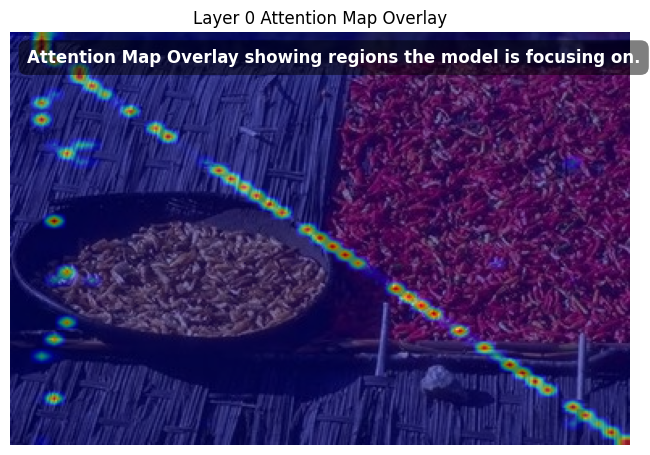

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_attention_on_image_with_legend(image, attn_map, title="", legend_text="", save_path=None):
    # Convert image to numpy for overlay
    image_np = np.array(image)

    # Resize the attention map to match the image size (or patch grid size)
    attn_map_resized = torch.nn.functional.interpolate(attn_map.unsqueeze(0).unsqueeze(0), size=image_np.shape[:2], mode='bilinear', align_corners=False)
    attn_map_resized = attn_map_resized.squeeze().cpu().numpy()

    # Normalize the attention map to [0, 1] range
    attn_map_resized = (attn_map_resized - attn_map_resized.min()) / (attn_map_resized.max() - attn_map_resized.min())

    # Create an overlay with the original image
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image_np)
    ax.imshow(attn_map_resized, cmap='jet', alpha=0.5)  # Overlay attention map with transparency
    ax.set_title(title)
    ax.axis("off")

    # Ajouter une légende sur l'image
    ax.text(10, 10, legend_text, color='white', fontsize=12, weight='bold', ha='left', va='top', bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.5'))

    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()
    plt.close()

# --- Visualiser la 1ère carte d'attention avec légende ---
if attention_maps:
    legend_text = "Attention Map Overlay showing regions the model is focusing on."
    visualize_attention_on_image_with_legend(image, attention_maps[0][0], title="Layer 0 Attention Map Overlay", legend_text=legend_text)


In [ ]:
# ==============================================================================
# BLOC D'ANALYSE RAPIDE : PARAMÈTRES ET GFLOPs
# Ce bloc est autonome et ne nécessite pas de recompiler le reste du code.
# ==============================================================================

# --- Installation des dépendances si nécessaire ---
!pip install thop timm

# --- Imports nécessaires pour cette analyse ---
import torch
import torch.nn as nn
import timm
import os
import logging
from torch.nn.modules.transformer import TransformerEncoderLayer
import torch.nn.functional as F
from torch.nn.init import xavier_uniform_, constant_
from thop import profile
from typing import Optional, Tuple

# --- Configuration du Logging (pour éviter les messages d'erreur) ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# --- 1. Définitions minimales requises pour charger le modèle ---
# (Copiez-collez uniquement les classes nécessaires à la construction du modèle)

class GeM(nn.Module):
    def __init__(self, p=3, eps=1e-6):
        super(GeM, self).__init__(); self.p = nn.Parameter(torch.ones(1) * p); self.eps = eps
    def forward(self, x): return F.adaptive_avg_pool2d(x.clamp(min=self.eps).pow(self.p), (1, 1)).pow(1./self.p)

class CBAM(nn.Module):
    def __init__(self, c, reduction_ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_avg_pool=nn.AdaptiveAvgPool2d(1); self.channel_max_pool=nn.AdaptiveMaxPool2d(1)
        self.channel_mlp=nn.Sequential(nn.Conv2d(c,c//reduction_ratio,1,bias=False),nn.ReLU(),nn.Conv2d(c//reduction_ratio,c,1,bias=False))
        self.channel_sigmoid=nn.Sigmoid()
        self.spatial_conv=nn.Conv2d(2,1,kernel_size=kernel_size,padding=kernel_size//2,bias=False); self.spatial_bn=nn.BatchNorm2d(1); self.spatial_sigmoid=nn.Sigmoid()
        for m in self.modules():
            if isinstance(m,nn.Conv2d): nn.init.kaiming_normal_(m.weight,mode='fan_out',nonlinearity='relu')
    def forward(self, x):
        avg_pool_ca=self.channel_avg_pool(x); max_pool_ca=self.channel_max_pool(x)
        mlp_avg=self.channel_mlp(avg_pool_ca); mlp_max=self.channel_mlp(max_pool_ca)
        channel_att=self.channel_sigmoid(mlp_avg+mlp_max); x_ca=x*channel_att
        max_out_sa,_=torch.max(x_ca,dim=1,keepdim=True); avg_out_sa=torch.mean(x_ca,dim=1,keepdim=True)
        sa_cat=torch.cat([max_out_sa,avg_out_sa],dim=1); sa_conv=self.spatial_conv(sa_cat)
        sa_bn=self.spatial_bn(sa_conv); spatial_att=self.spatial_sigmoid(sa_bn); out=x_ca*spatial_att
        return out

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dr=0.1, max_len=10):
        super(PositionalEncoding,self).__init__(); self.dropout=nn.Dropout(p=dr)
        pe=torch.zeros(max_len,d_model); position=torch.arange(0,max_len,dtype=torch.float).unsqueeze(1)
        div_term=torch.exp(torch.arange(0,d_model,2).float()*(-np.log(10000.0)/d_model))
        pe[:,0::2]=torch.sin(position*div_term); pe[:,1::2]=torch.cos(position*div_term)
        self.register_buffer('pe',pe.unsqueeze(0))
    def forward(self, x): return self.dropout(x + self.pe[:,:x.size(1),:])

class TransformerEncoderLayerWithAttention(TransformerEncoderLayer):
    def _sa_block(self,x,attn_mask,key_padding_mask):
        x_attn,attn_weights=self.self_attn(x,x,x,attn_mask=attn_mask,key_padding_mask=key_padding_mask,need_weights=True,average_attn_weights=False)
        return self.dropout1(x_attn),attn_weights
    def forward(self,src,src_mask=None,src_key_padding_mask=None):
        attn_weights=None
        if self.norm_first:
            sa_norm=self.norm1(src); sa_out,attn_weights=self._sa_block(sa_norm,src_mask,src_key_padding_mask); x=src+sa_out
            ff_norm=self.norm2(x); x=x+self._ff_block(ff_norm)
        else:
            sa_out,attn_weights=self._sa_block(src,src_mask,src_key_padding_mask); x=self.norm1(src+sa_out)
            ff_out=self._ff_block(x); x=self.norm2(x+ff_out)
        return x, attn_weights

class MidLevelFusionTransformerV2(nn.Module):
    def __init__(self, num_classes=2, embed_dim=256, num_heads=8, num_layers=4, dropout_rate=0.3):
        super().__init__()
        # Note: on ne met pas .to(DEVICE) ici pour que le modèle soit initialisé sur CPU par défaut
        self.swin=timm.create_model("swin_small_patch4_window7_224",pretrained=False,features_only=True)
        self.efficientnet=timm.create_model("efficientnet_b2",pretrained=False,features_only=True)
        self.swin_feature_index=-1; swin_feature_dim=self.swin.feature_info[self.swin_feature_index]['num_chs']
        self.efficientnet_feature_index=4; efficientnet_feature_dim=self.efficientnet.feature_info[self.efficientnet_feature_index]['num_chs']
        self.cbam_efficientnet=CBAM(c=efficientnet_feature_dim); self.cbam_swin=CBAM(c=swin_feature_dim)
        self.pool=GeM()
        self.swin_proj=nn.Linear(swin_feature_dim,embed_dim); self.efficientnet_proj=nn.Linear(efficientnet_feature_dim,embed_dim)
        encoder_layer=TransformerEncoderLayerWithAttention(d_model=embed_dim,nhead=num_heads,batch_first=True,dropout=0.2,dim_feedforward=embed_dim*4)
        self.transformer_encoder=nn.TransformerEncoder(encoder_layer,num_layers=num_layers)
        self.positional_encoding=PositionalEncoding(d_model=embed_dim,dr=0.1,max_len=10)
        self.classifier=nn.Linear(embed_dim,num_classes); self.classifier_dropout=nn.Dropout(dropout_rate)
        for m in[self.swin_proj,self.efficientnet_proj,self.classifier]:
            if isinstance(m,nn.Linear): xavier_uniform_(m.weight); constant_(m.bias,0.)
    def forward(self,image):
        swin_features_list=self.swin(image); efficientnet_features_list=self.efficientnet(image)
        swin_features_raw=swin_features_list[self.swin_feature_index].permute(0,3,1,2).contiguous()
        efficientnet_features_raw=efficientnet_features_list[self.efficientnet_feature_index].contiguous()
        swin_features_cbam=self.cbam_swin(swin_features_raw); efficientnet_features_cbam=self.cbam_efficientnet(efficientnet_features_raw)
        swin_features_pooled=self.pool(swin_features_cbam).flatten(1); efficientnet_features_pooled=self.pool(efficientnet_features_cbam).flatten(1)
        swin_features_proj=self.swin_proj(swin_features_pooled); efficientnet_features_proj=self.efficientnet_proj(efficientnet_features_pooled)
        fused_features_sequence=torch.stack([swin_features_proj,efficientnet_features_proj],dim=1)
        fused_features_sequence=self.positional_encoding(fused_features_sequence)
        transformer_output_sequence=fused_features_sequence
        for layer in self.transformer_encoder.layers:
            transformer_output_sequence,_=layer(transformer_output_sequence)
        fused_representation=transformer_output_sequence.mean(dim=1)
        output=self.classifier(self.classifier_dropout(fused_representation))
        return output,None,None,None # Signature de retour modifiée pour la simplicité


# --- 2. Code d'Analyse ---
try:
    # --- Configuration ---
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    IMG_SIZE = 224 # Doit correspondre à la taille utilisée à l'entraînement

    # !! IMPORTANT : MODIFIEZ CECI pour pointer vers votre meilleur modèle !!
    MODEL_PATH = "best_model_mid_fusion_tf_v2_gem_cbam_ls_balanced_phase2.pth"

    print(f"Analyse du modèle : {MODEL_PATH}")
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(f"Le fichier modèle '{MODEL_PATH}' n'a pas été trouvé. Veuillez vérifier le chemin.")

    # --- Chargement de l'architecture (sans les poids pré-entraînés de timm) ---
    model = MidLevelFusionTransformerV2(num_classes=2)
    # --- Chargement de VOS poids entraînés ---
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    # --- Affichage des Résultats ---
    print("\n" + "="*40)
    print("--- MÉTRIQUES D'EFFICACITÉ DU MODÈLE ---")
    print("="*40)

    # 1. Calcul du Nombre de Paramètres
    params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"-> Nombre de Paramètres (M) : {params_trainable / 1_000_000:.2f} M")

    # 2. Calcul des GFLOPs
    dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

    # Wrapper pour gérer la sortie multiple du modèle
    class ModelWrapperForThop(nn.Module):
        def __init__(self, model):
            super().__init__(); self.model = model
        def forward(self, x):
            # Le wrapper appelle le modèle et retourne uniquement la première sortie (les logits)
            return self.model(x)[0]

    wrapped_model = ModelWrapperForThop(model)
    macs, _ = profile(wrapped_model, inputs=(dummy_input,), verbose=False)
    gflops = (macs * 2) / 1_000_000_000
    print(f"-> Complexité (GFLOPs)       : {gflops:.2f}")
    print("="*40 + "\n")

except Exception as e:
    print(f"\nUNE ERREUR EST SURVENUE : {e}")

Analyse du modèle : best_model_mid_fusion_tf_v2_gem_cbam_ls_balanced_phase2.pth

UNE ERREUR EST SURVENUE : Le fichier modèle 'best_model_mid_fusion_tf_v2_gem_cbam_ls_balanced_phase2.pth' n'a pas été trouvé. Veuillez vérifier le chemin.


In [ ]:
!ls -l /content/drive/MyDrive/


ls: cannot access '/content/drive/MyDrive/': No such file or directory


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
from timm import create_model
import sys

# ✅ Configuration
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 16
IMG_SIZE = 224
NUM_CLASSES = 2
EPOCHS = 2
LEARNING_RATE = 1e-4

# ✅ Dataset fictif pour test
X = torch.randn(100, 3, IMG_SIZE, IMG_SIZE)
y = torch.randint(0, NUM_CLASSES, (100,))
train_dataset = TensorDataset(X, y)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# ✅ Modèle personnalisé
class MidLevelFusionTransformerV2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.swin = create_model("swin_small_patch4_window7_224", pretrained=True, num_classes=0)
        self.effnet = create_model("efficientnet_b2", pretrained=True, num_classes=0)

        for p in self.swin.parameters():
            p.requires_grad = False
        for p in self.effnet.parameters():
            p.requires_grad = False

        self.fusion = nn.Sequential(
            nn.Linear(self.swin.num_features + self.effnet.num_features, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        swin_features = self.swin(x)
        effnet_features = self.effnet(x)

        print("📦 Swin:", swin_features.shape, file=sys.stderr)
        print("📦 Effnet:", effnet_features.shape, file=sys.stderr)

        features = torch.cat((swin_features, effnet_features), dim=1)
        return self.fusion(features)

# ✅ Initialisation
model = MidLevelFusionTransformerV2(NUM_CLASSES).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()
scaler = GradScaler()

# ✅ Entraînement
print("🚀 Démarrage de l'entraînement...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for inputs, labels in pbar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        with autocast():  # OK sans device_type, détecte 'cuda' automatiquement
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=running_loss / (pbar.n + 1))

print("✅ Entraînement terminé.")


2025-06-29 16:25:51,886 - INFO - Loading pretrained weights from Hugging Face hub (timm/swin_small_patch4_window7_224.ms_in22k_ft_in1k)
2025-06-29 16:25:51,983 - INFO - [timm/swin_small_patch4_window7_224.ms_in22k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
2025-06-29 16:25:52,154 - INFO - Loading pretrained weights from Hugging Face hub (timm/efficientnet_b2.ra_in1k)
2025-06-29 16:25:52,228 - INFO - [timm/efficientnet_b2.ra_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
/tmp/ipython-input-20-1208538084.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


🚀 Démarrage de l'entraînement...


Epoch 1/2:   0%|          | 0/7 [00:00<?, ?it/s]/tmp/ipython-input-20-1208538084.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # OK sans device_type, détecte 'cuda' automatiquement
📦 Swin: torch.Size([16, 768])
📦 Effnet: torch.Size([16, 1408])
Epoch 1/2:  14%|█▍        | 1/7 [00:00<00:02,  2.88it/s, loss=0.687]📦 Swin: torch.Size([16, 768])
📦 Effnet: torch.Size([16, 1408])
Epoch 1/2:  14%|█▍        | 1/7 [00:00<00:02,  2.88it/s, loss=0.717]📦 Swin: torch.Size([16, 768])
📦 Effnet: torch.Size([16, 1408])
Epoch 1/2:  43%|████▎     | 3/7 [00:00<00:00,  7.31it/s, loss=1.05]📦 Swin: torch.Size([16, 768])
📦 Effnet: torch.Size([16, 1408])
Epoch 1/2:  43%|████▎     | 3/7 [00:00<00:00,  7.31it/s, loss=0.705]📦 Swin: torch.Size([16, 768])
📦 Effnet: torch.Size([16, 1408])
Epoch 1/2:  71%|███████▏  | 5/7 [00:00<00:00, 10.22it/s, loss=0.87]📦 Swin: torch.Size([16, 768])
📦 Effnet: torch.Size([16, 1408])

✅ Entraînement terminé.


In [ ]:
torch.save(model.state_dict(), "midfusion_v2.pth")
print("📦 Modèle sauvegardé dans midfusion_v2.pth")


📦 Modèle sauvegardé dans midfusion_v2.pth


In [ ]:
def summarize_model(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print("\n📊 === Résumé du Modèle ===")
    print(f"🔧 Backbone Swin utilisé : timm/swin_small_patch4_window7_224.ms_in22k_ft_in1k")
    print(f"⚙️  Backbone EfficientNet utilisé : timm/efficientnet_b2.ra_in1k")
    print(f"🧠 Nombre total de paramètres      : {total_params:,}")
    print(f"🧪 Nombre de paramètres entraînables : {trainable_params:,}")
    print(f"❄️ Swin gelé ? {'Oui' if not any(p.requires_grad for p in model.swin.parameters()) else 'Non'}")
    print(f"🔄 EffNet gelé ? {'Oui' if not any(p.requires_grad for p in model.effnet.parameters()) else 'Non'}")
    print(f"🧱 Architecture de fusion : {type(model).__name__}")
    print("==============================\n")

# Utilisation après avoir défini le modèle
summarize_model(model)



📊 === Résumé du Modèle ===
🔧 Backbone Swin utilisé : timm/swin_small_patch4_window7_224.ms_in22k_ft_in1k
⚙️  Backbone EfficientNet utilisé : timm/efficientnet_b2.ra_in1k
🧠 Nombre total de paramètres      : 57,653,902
🧪 Nombre de paramètres entraînables : 1,115,650
❄️ Swin gelé ? Oui
🔄 EffNet gelé ? Oui
🧱 Architecture de fusion : MidLevelFusionTransformerV2



In [ ]:
print("➡️ Input shape:", inputs.shape)
if inputs.shape[2] <= 0 or inputs.shape[3] <= 0:
    raise ValueError(f"Image height or width is invalid: {inputs.shape}")


➡️ Input shape: torch.Size([16, 3, 224, 224])


In [ ]:
!pip install torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.6/962.6 kB 14.9 MB/s eta 0:00:00


In [ ]:
!pip install thop


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 102.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvj